# GNN for Spatial Cascade Propagation

**Goal:** Given a primary disaster event in a county, predict which **neighboring counties**
will experience secondary (cascaded) disaster events — and what types.

| Component | Detail |
|---|---|
| **Graph** | ~3,100 county nodes, ~18K adjacency edges (US Census) |
| **Input** | Per-episode subgraph: primary event features seeded at source county |
| **Prediction** | For each county within 2 hops: will it see a cascade? What type? |
| **Model** | 2-layer GAT that propagates disaster risk from source to neighbors |
| **Fairness angle** | Under-reported counties get predictions via neighbor signal |
| **Visualization** | Animated disaster propagation across county graph |

In [39]:
import numpy as np
import pandas as pd
import pickle
import time
import warnings
import ast
import os
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss,
    precision_recall_curve, roc_curve, auc
)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__}  \u2022  Device: {DEVICE}")

%matplotlib inline

PyTorch 2.8.0  •  Device: cpu


In [40]:
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv
from torch_geometric.utils import add_self_loops, subgraph, k_hop_subgraph
import geopandas as gpd
import requests
print(f"PyG {torch_geometric.__version__}")

PyG 2.6.1


---
## 1. Data Loading & County Graph

In [41]:
DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
CACHE_DIR = DATA_DIR / 'gnn_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path('../models/gnn')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path('../results/gnn')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading events ...")
events = pd.read_csv(
    PROCESSED_DIR / 'events_labeled_full.csv',
    usecols=[
        'EVENT_ID', 'EPISODE_ID', 'EVENT_TYPE', 'STATE', 'STATE_FIPS',
        'CZ_FIPS', 'CZ_TYPE', 'CZ_NAME', 'LOCATION_KEY',
        'BEGIN_DATETIME', 'END_DATETIME',
        'BEGIN_LAT', 'BEGIN_LON',
        'MAGNITUDE', 'INJURIES_DIRECT', 'INJURIES_INDIRECT',
        'DEATHS_DIRECT', 'DEATHS_INDIRECT',
        'DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD', 'TOTAL_DAMAGE_USD',
        'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH',
        'target', 'is_cascade', 'is_cascade_result',
    ],
    parse_dates=['BEGIN_DATETIME', 'END_DATETIME'],
)
print(f"  Total events: {len(events):,}")

# County-type only (reliable FIPS)
events = events[events['CZ_TYPE'] == 'C'].copy()
events['FIPS'] = (events['STATE_FIPS'].astype(str).str.zfill(2) +
                  events['CZ_FIPS'].astype(str).str.zfill(3))
print(f"  County events: {len(events):,}, {events['FIPS'].nunique()} counties")

# Parse targets
events['target_parsed'] = events['target'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else [])
events['has_cascade'] = events['target_parsed'].apply(lambda x: len(x) > 0)
events['is_cascade_result'] = events['is_cascade_result'].isin([True, 'True', 1])
events['year'] = events['BEGIN_DATETIME'].dt.year

print(f"  Events triggering cascades: {events['has_cascade'].sum():,}")
print(f"  Events that are cascade results: {events['is_cascade_result'].sum():,}")

Loading events ...
  Total events: 967,441
  County events: 559,620, 3267 counties
  Events triggering cascades: 144,800
  Events that are cascade results: 138,853


In [42]:
# ── County adjacency graph ────────────────────────────────────────────
ADJ_CACHE = CACHE_DIR / 'county_adjacency.csv'
if ADJ_CACHE.exists():
    print("Loading cached county adjacency ...")
    adj_df = pd.read_csv(ADJ_CACHE, dtype=str)
else:
    print("Downloading US Census county adjacency file ...")
    url = "https://www2.census.gov/geo/docs/reference/county_adjacency/county_adjacency2023.txt"
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    import io
    raw_df = pd.read_csv(io.StringIO(resp.text), sep='|', dtype=str)
    raw_df.columns = ['county_name', 'county_fips', 'neighbor_name', 'neighbor_fips']
    adj_df = raw_df[['county_fips', 'neighbor_fips']].dropna().copy()
    adj_df.to_csv(ADJ_CACHE, index=False)

adj_df = adj_df[adj_df['county_fips'] != adj_df['neighbor_fips']].copy()

# Build node set: counties in both events and adjacency
event_fips = set(events['FIPS'].unique())
adj_fips = set(adj_df['county_fips']) | set(adj_df['neighbor_fips'])
common_fips = sorted(event_fips & adj_fips)
fips_to_idx = {f: i for i, f in enumerate(common_fips)}
idx_to_fips = {i: f for f, i in fips_to_idx.items()}
N_NODES = len(common_fips)

# Filter events
events = events[events['FIPS'].isin(common_fips)].copy()

# Build edge_index
src, dst = [], []
for _, row in adj_df.iterrows():
    s, d = row['county_fips'], row['neighbor_fips']
    if s in fips_to_idx and d in fips_to_idx:
        src.append(fips_to_idx[s])
        dst.append(fips_to_idx[d])
        # Add reverse for undirected
        src.append(fips_to_idx[d])
        dst.append(fips_to_idx[s])

edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_index = torch.unique(edge_index, dim=1)
edge_index, _ = add_self_loops(edge_index, num_nodes=N_NODES)

# Precompute neighbor sets for fast lookup
neighbor_map = defaultdict(set)
ei_np = edge_index.numpy()
for e in range(ei_np.shape[1]):
    s, d = ei_np[0, e], ei_np[1, e]
    if s != d:
        neighbor_map[s].add(d)

print(f"Graph: {N_NODES} nodes, {edge_index.shape[1]} edges")
print(f"Avg degree: {edge_index.shape[1] / N_NODES:.1f}")

# County centroids for visualization
county_coords = events.groupby('FIPS').agg(
    lat=('BEGIN_LAT', 'median'),
    lon=('BEGIN_LON', 'median'),
    state=('STATE', 'first'),
    name=('CZ_NAME', 'first'),
).reindex(common_fips).fillna(0)
print(f"County centroids: {len(county_coords)}")

Loading cached county adjacency ...
Graph: 3104 nodes, 21496 edges
Avg degree: 6.9
County centroids: 3104


---
## 2. Episode-Level Training Data

Each training sample is one **episode** (weather system). The task:
- **Input**: Features of the primary/trigger events, seeded at their source counties
- **Output**: For each county in the local subgraph (2 hops from any source),
  predict a multi-hot vector of which cascade types will occur there

The GAT propagates the primary event signal outward through the county
adjacency graph to predict where cascades will land.

In [43]:
# ── Event type encoding ───────────────────────────────────────────────
EVENT_TYPES = sorted(events['EVENT_TYPE'].unique())
N_EVENT_TYPES = len(EVENT_TYPES)
etype_to_idx = {e: i for i, e in enumerate(EVENT_TYPES)}

# ── Target labels ─────────────────────────────────────────────────────
target_counts = defaultdict(int)
for t_list in events['target_parsed']:
    for t in t_list:
        target_counts[t] += 1

MIN_COUNT = 200
TARGET_NAMES = sorted([t for t, c in target_counts.items() if c >= MIN_COUNT])
N_LABELS = len(TARGET_NAMES)
target_to_idx = {t: i for i, t in enumerate(TARGET_NAMES)}

print(f"Event types: {N_EVENT_TYPES}")
print(f"Target labels: {N_LABELS}")
for t in TARGET_NAMES:
    print(f"  {t}: {target_counts[t]:,}")

# ── Per-event feature vector ──────────────────────────────────────────
# [event_type_onehot (N_EVENT_TYPES), log_damage, magnitude,
#  injuries, deaths, duration_hours]
N_EVENT_FEATURES = N_EVENT_TYPES + 5
print(f"\nPer-event feature dim: {N_EVENT_FEATURES}")


def _safe_float(val, default=0.0):
    """Convert value to float, handling NaN/None."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return default
    try:
        return float(val)
    except (ValueError, TypeError):
        return default


def event_to_features(row):
    """Convert one event row to a feature vector."""
    feat = np.zeros(N_EVENT_FEATURES, dtype=np.float32)
    # One-hot event type
    if row['EVENT_TYPE'] in etype_to_idx:
        feat[etype_to_idx[row['EVENT_TYPE']]] = 1.0
    # Continuous features
    feat[N_EVENT_TYPES + 0] = np.log1p(max(_safe_float(row.get('TOTAL_DAMAGE_USD')), 0))
    feat[N_EVENT_TYPES + 1] = max(_safe_float(row.get('MAGNITUDE')), 0)
    feat[N_EVENT_TYPES + 2] = (max(_safe_float(row.get('INJURIES_DIRECT')), 0) +
                                max(_safe_float(row.get('INJURIES_INDIRECT')), 0))
    feat[N_EVENT_TYPES + 3] = (max(_safe_float(row.get('DEATHS_DIRECT')), 0) +
                                max(_safe_float(row.get('DEATHS_INDIRECT')), 0))
    if pd.notna(row.get('BEGIN_DATETIME')) and pd.notna(row.get('END_DATETIME')):
        feat[N_EVENT_FEATURES - 1] = max(
            (row['END_DATETIME'] - row['BEGIN_DATETIME']).total_seconds() / 3600, 0)
    return feat

Event types: 20
Target labels: 7
  Debris Flow: 1,294
  Flash Flood: 43,261
  Flood: 9,842
  Hail: 46,689
  Lightning: 6,379
  Thunderstorm Wind: 47,699
  Tornado: 11,464

Per-event feature dim: 25


In [44]:
# ── Build episode-level PyG Data objects ──────────────────────────────
# For each episode with cascades:
#   1. Find primary (trigger) events and their counties
#   2. Extract 2-hop subgraph around those counties
#   3. Node features: sum of primary event features at source counties (0 elsewhere)
#   4. Node labels: multi-hot cascade types that actually occurred at each county

print("Building episode graphs ...")
t0 = time.time()

cascade_episode_ids = events[events['has_cascade']]['EPISODE_ID'].unique()
print(f"  Episodes with cascades: {len(cascade_episode_ids):,}")

episode_data = []  # list of PyG Data objects
skipped = 0

for ep_id in cascade_episode_ids:
    ep = events[events['EPISODE_ID'] == ep_id]
    
    # Primary events: those that trigger cascades
    primaries = ep[ep['has_cascade']]
    primary_counties = primaries['FIPS'].unique()
    primary_node_ids = [fips_to_idx[f] for f in primary_counties if f in fips_to_idx]
    
    if len(primary_node_ids) == 0:
        skipped += 1
        continue
    
    # Get 2-hop subgraph around primary counties
    center_nodes = torch.tensor(primary_node_ids, dtype=torch.long)
    sub_nodes, sub_edge_index, node_mapping, _ = k_hop_subgraph(
        center_nodes, num_hops=2, edge_index=edge_index,
        relabel_nodes=True, num_nodes=N_NODES
    )
    n_sub = len(sub_nodes)
    
    if n_sub < 2:
        skipped += 1
        continue
    
    # Build node features: aggregate primary event features at source counties
    x = np.zeros((n_sub, N_EVENT_FEATURES), dtype=np.float32)
    for _, row in primaries.iterrows():
        if row['FIPS'] in fips_to_idx:
            global_idx = fips_to_idx[row['FIPS']]
            # Find local index in subgraph
            local_mask = (sub_nodes == global_idx).nonzero(as_tuple=True)[0]
            if len(local_mask) > 0:
                local_idx = local_mask[0].item()
                x[local_idx] += event_to_features(row)
    
    # Build node labels: what cascade types occurred at each county?
    y = np.zeros((n_sub, N_LABELS), dtype=np.float32)
    # Look at ALL events in episode (including cascade results)
    for _, row in ep.iterrows():
        if row['FIPS'] in fips_to_idx:
            global_idx = fips_to_idx[row['FIPS']]
            local_mask = (sub_nodes == global_idx).nonzero(as_tuple=True)[0]
            if len(local_mask) > 0:
                local_idx = local_mask[0].item()
                # If this event is a cascade result, mark its type as a label
                if row['is_cascade_result']:
                    etype = row['EVENT_TYPE']
                    if etype in target_to_idx:
                        y[local_idx, target_to_idx[etype]] = 1.0
    
    # Mark which nodes are source (primary) counties
    is_source = np.zeros(n_sub, dtype=np.float32)
    for ni in node_mapping:
        is_source[ni.item()] = 1.0
    
    # Create PyG Data
    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=sub_edge_index,
        y=torch.tensor(y, dtype=torch.float32),
        is_source=torch.tensor(is_source, dtype=torch.float32),
        global_node_ids=sub_nodes,
        episode_id=ep_id,
        year=primaries['year'].iloc[0],
    )
    episode_data.append(data)

elapsed = time.time() - t0
print(f"\nBuilt {len(episode_data):,} episode graphs in {elapsed:.0f}s (skipped {skipped})")

# Stats
n_nodes_list = [d.x.shape[0] for d in episode_data]
print(f"Nodes per episode: mean={np.mean(n_nodes_list):.0f}, "
      f"median={np.median(n_nodes_list):.0f}, max={max(n_nodes_list)}")

# Positive label rate
all_y = torch.cat([d.y for d in episode_data], dim=0).numpy()
print(f"\nLabel distribution across all episode-county pairs:")
for i, t in enumerate(TARGET_NAMES):
    pos = all_y[:, i].sum()
    print(f"  {t:25s}: {int(pos):,} positive ({pos / len(all_y) * 100:.2f}%)")

Building episode graphs ...
  Episodes with cascades: 29,542

Built 29,503 episode graphs in 35s (skipped 39)
Nodes per episode: mean=27, median=23, max=144

Label distribution across all episode-county pairs:
  Debris Flow              : 309 positive (0.04%)
  Flash Flood              : 10,755 positive (1.37%)
  Flood                    : 3,205 positive (0.41%)
  Hail                     : 20,376 positive (2.60%)
  Lightning                : 1,644 positive (0.21%)
  Thunderstorm Wind        : 21,279 positive (2.72%)
  Tornado                  : 4,539 positive (0.58%)


In [45]:
# ── Chronological split ──────────────────────────────────────────────
train_data = [d for d in episode_data if d.year <= 2022]
val_data   = [d for d in episode_data if d.year == 2023]
test_data  = [d for d in episode_data if d.year >= 2024]

print(f"Train: {len(train_data):,} episodes (<=2022)")
print(f"Val:   {len(val_data):,} episodes (2023)")
print(f"Test:  {len(test_data):,} episodes (>=2024)")

# ── Normalize features ───────────────────────────────────────────────
# Only fit on SOURCE nodes (non-zero) to avoid zero-dominated statistics.
# Non-source nodes stay at zero — the model should learn that zero = no event.
X_source_all = []
for d in train_data:
    src_mask = d.is_source > 0.5
    if src_mask.sum() > 0:
        X_source_all.append(d.x[src_mask])
X_source_all = torch.cat(X_source_all, dim=0).numpy()

# Compute max absolute value per feature for simple normalization
feat_max = np.maximum(np.abs(X_source_all).max(axis=0), 1e-8)
print(f"Scaler fitted on {X_source_all.shape[0]:,} source nodes")

# Apply normalization: divide by max (preserves zeros)
for d in episode_data:
    d.x_scaled = d.x / torch.tensor(feat_max, dtype=torch.float32)

# ── Class weights (capped at 10 for stability) ──────────────────────
Y_train_all = torch.cat([d.y for d in train_data], dim=0).numpy()
pos_counts = Y_train_all.sum(axis=0)
neg_counts = Y_train_all.shape[0] - pos_counts
pos_weight = np.clip(neg_counts / (pos_counts + 1), 1.0, 10.0)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

print("\nClass weights (capped at 10):")
for i, t in enumerate(TARGET_NAMES):
    print(f"  {t:25s}: pos={int(pos_counts[i]):6,}  weight={pos_weight[i]:.1f}")

Train: 23,878 episodes (<=2022)
Val:   2,055 episodes (2023)
Test:  3,570 episodes (>=2024)
Scaler fitted on 45,607 source nodes

Class weights (capped at 10):
  Debris Flow              : pos=   239  weight=10.0
  Flash Flood              : pos= 8,603  weight=10.0
  Flood                    : pos= 2,629  weight=10.0
  Hail                     : pos=16,444  weight=10.0
  Lightning                : pos= 1,426  weight=10.0
  Thunderstorm Wind        : pos=17,124  weight=10.0
  Tornado                  : pos= 3,433  weight=10.0


---
## 3. GNN Model \u2014 `CascadePropagationGAT`

The model takes a subgraph where **source counties** are seeded with primary event
features and all other nodes start at zero. The GAT's message passing propagates
the disaster signal outward through geographic neighbors.

- **Layer 1**: 4-head GAT \u2014 source signal spreads to immediate neighbors
- **Layer 2**: Single-head GAT \u2014 signal reaches 2-hop counties
- **Classifier**: MLP predicts cascade probability per county per disaster type

In [46]:
class CascadePropagationGAT(nn.Module):
    """GAT that propagates disaster risk from source counties to neighbors.
    
    Input: event features seeded at source counties, zeros elsewhere.
    Output: per-county, per-label cascade probability.
    """
    def __init__(self, in_dim, hidden_dim=64, n_labels=8,
                 n_heads=4, dropout=0.3):
        super().__init__()
        # Input projection (+ 1 for is_source flag)
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        # GAT Layer 1: multi-head
        self.gat1 = GATConv(
            hidden_dim, hidden_dim // n_heads,
            heads=n_heads, dropout=dropout, concat=True,
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        # GAT Layer 2: single-head
        self.gat2 = GATConv(
            hidden_dim, hidden_dim,
            heads=1, dropout=dropout, concat=False,
        )
        self.norm2 = nn.LayerNorm(hidden_dim)
        # MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, n_labels),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, is_source, return_attention=False):
        # Concat source flag to features
        h = torch.cat([x, is_source.unsqueeze(-1)], dim=-1)
        h = self.input_proj(h)
        
        # GAT Layer 1 + residual
        h1, attn1 = self.gat1(h, edge_index, return_attention_weights=True)
        h = self.norm1(F.elu(h1) + h)
        h = self.dropout(h)
        
        # GAT Layer 2 + residual
        h2, attn2 = self.gat2(h, edge_index, return_attention_weights=True)
        h = self.norm2(F.elu(h2) + h)
        h = self.dropout(h)
        
        logits = self.classifier(h)
        
        if return_attention:
            return logits, (attn1, attn2)
        return logits


model = CascadePropagationGAT(
    in_dim=N_EVENT_FEATURES, hidden_dim=64, n_labels=N_LABELS,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"CascadePropagationGAT: {n_params:,} parameters")

CascadePropagationGAT: 27,719 parameters


---
## 4. Training

In [47]:
def train_one_epoch(model, data_list, criterion, optimizer, batch_size=64):
    """Train on mini-batches of episodes."""
    model.train()
    total_loss = 0
    n_nodes = 0
    
    # Shuffle episodes
    indices = np.random.permutation(len(data_list))
    
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        batch = Batch.from_data_list(
            [data_list[i] for i in batch_idx])
        
        x = batch.x_scaled.to(DEVICE)
        ei = batch.edge_index.to(DEVICE)
        y = batch.y.to(DEVICE)
        is_src = batch.is_source.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(x, ei, is_src)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        n_nodes += x.size(0)
    
    return total_loss / n_nodes


@torch.no_grad()
def evaluate(model, data_list, criterion, batch_size=128):
    """Evaluate on episodes. Returns loss, probs, labels."""
    model.eval()
    total_loss = 0
    n_nodes = 0
    all_probs, all_labels, all_sources = [], [], []
    
    for start in range(0, len(data_list), batch_size):
        batch = Batch.from_data_list(
            data_list[start:start + batch_size])
        
        x = batch.x_scaled.to(DEVICE)
        ei = batch.edge_index.to(DEVICE)
        y = batch.y.to(DEVICE)
        is_src = batch.is_source.to(DEVICE)
        
        logits = model(x, ei, is_src)
        loss = criterion(logits, y)
        
        total_loss += loss.item() * x.size(0)
        n_nodes += x.size(0)
        
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y.cpu().numpy())
        all_sources.append(is_src.cpu().numpy())
    
    return (total_loss / n_nodes,
            np.concatenate(all_probs),
            np.concatenate(all_labels),
            np.concatenate(all_sources))


def tune_thresholds(y_true, y_prob, min_thresh=0.05):
    """Per-label threshold tuning to maximize F1."""
    thresholds = np.full(y_true.shape[1], 0.5)
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() == 0:
            continue
        precs, recs, ths = precision_recall_curve(y_true[:, i], y_prob[:, i])
        f1s = 2 * precs * recs / (precs + recs + 1e-8)
        best = np.argmax(f1s)
        if best < len(ths):
            thresholds[i] = max(ths[best], min_thresh)
    return thresholds


def compute_metrics(y_true, y_prob, thresholds, target_names, is_source=None):
    """Compute metrics. Optionally split by source vs non-source nodes."""
    y_pred = (y_prob >= thresholds).astype(int)
    
    results = {}
    results['f1_macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
    results['f1_micro'] = f1_score(y_true, y_pred, average='micro', zero_division=0)
    results['precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    results['recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    results['hamming_loss'] = hamming_loss(y_true, y_pred)
    
    try:
        results['aucpr_macro'] = average_precision_score(y_true, y_prob, average='macro')
    except:
        results['aucpr_macro'] = 0.0
    
    # Per-label metrics
    per_label = []
    for j, lbl in enumerate(target_names):
        sup = int(y_true[:, j].sum())
        per_label.append(dict(
            label=lbl, support=sup,
            f1=f1_score(y_true[:, j], y_pred[:, j], zero_division=0),
            precision=precision_score(y_true[:, j], y_pred[:, j], zero_division=0),
            recall=recall_score(y_true[:, j], y_pred[:, j], zero_division=0),
        ))
    
    # Source vs non-source breakdown (the key metric: can we predict at NON-source counties?)
    if is_source is not None:
        src_mask = is_source > 0.5
        nonsrc_mask = ~src_mask
        if nonsrc_mask.sum() > 0 and y_true[nonsrc_mask].sum() > 0:
            results['f1_macro_nonsource'] = f1_score(
                y_true[nonsrc_mask], y_pred[nonsrc_mask], average='macro', zero_division=0)
            results['f1_macro_source'] = f1_score(
                y_true[src_mask], y_pred[src_mask], average='macro', zero_division=0)
    
    return results, pd.DataFrame(per_label)

print("Training utilities defined.")

Training utilities defined.


In [48]:
# ── Train ─────────────────────────────────────────────────────────────
EPOCHS = 60
PATIENCE = 12
LR = 3e-4
BATCH_SIZE = 32

model = CascadePropagationGAT(
    in_dim=N_EVENT_FEATURES, hidden_dim=64, n_labels=N_LABELS,
    n_heads=4, dropout=0.3,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print(f"Training: {len(train_data):,} episodes, {EPOCHS} epochs, batch={BATCH_SIZE}")
print("=" * 70)

best_val_f1 = -1
best_state = None
wait = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_data, criterion, optimizer, BATCH_SIZE)
    
    # Check for NaN
    if np.isnan(train_loss):
        print(f"  Epoch {epoch}: NaN loss detected, stopping.")
        break
    
    val_loss, val_probs, val_labels, val_src = evaluate(
        model, val_data, criterion)
    val_preds = (val_probs >= 0.5).astype(int)
    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
    
    scheduler.step(val_f1)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
    
    if epoch % 5 == 0 or epoch == 1 or wait == 0:
        marker = ' ★' if wait == 0 else ''
        elapsed = time.time() - t_start
        print(f"  Epoch {epoch:3d}  loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  val_f1={val_f1:.4f}  "
              f"[{elapsed:.0f}s]{marker}")
    
    if wait >= PATIENCE:
        print(f"  Early stop at epoch {epoch} (best val_f1={best_val_f1:.4f})")
        break

model.load_state_dict(best_state)
model.to(DEVICE)
print(f"\nDone in {time.time() - t_start:.0f}s. Best val F1: {best_val_f1:.4f}")

Training: 23,878 episodes, 60 epochs, batch=32
  Epoch   1  loss=0.1828  val_loss=0.1449  val_f1=0.1920  [6s] ★
  Epoch   2  loss=0.1433  val_loss=0.1330  val_f1=0.3275  [11s] ★
  Epoch   4  loss=0.1287  val_loss=0.1259  val_f1=0.3408  [22s] ★
  Epoch   5  loss=0.1248  val_loss=0.1206  val_f1=0.4116  [27s] ★
  Epoch   7  loss=0.1210  val_loss=0.1176  val_f1=0.4323  [36s] ★
  Epoch   8  loss=0.1199  val_loss=0.1181  val_f1=0.4453  [42s] ★
  Epoch  10  loss=0.1183  val_loss=0.1170  val_f1=0.4334  [52s]
  Epoch  11  loss=0.1178  val_loss=0.1177  val_f1=0.4556  [56s] ★
  Epoch  14  loss=0.1164  val_loss=0.1154  val_f1=0.4565  [71s] ★
  Epoch  15  loss=0.1163  val_loss=0.1156  val_f1=0.4532  [76s]
  Epoch  18  loss=0.1158  val_loss=0.1152  val_f1=0.4593  [91s] ★
  Epoch  20  loss=0.1155  val_loss=0.1153  val_f1=0.4484  [101s]
  Epoch  21  loss=0.1151  val_loss=0.1149  val_f1=0.4624  [106s] ★
  Epoch  24  loss=0.1149  val_loss=0.1145  val_f1=0.4671  [120s] ★
  Epoch  25  loss=0.1147  val_los

In [49]:
# ── Threshold tuning + test evaluation ────────────────────────────────
val_loss, val_probs, val_labels, val_src = evaluate(model, val_data, criterion)
thresholds = tune_thresholds(val_labels, val_probs)
print("Tuned thresholds:")
for i, t in enumerate(TARGET_NAMES):
    print(f"  {t:25s}: {thresholds[i]:.3f}")

test_loss, test_probs, test_labels, test_src = evaluate(model, test_data, criterion)
overall, per_label_df = compute_metrics(
    test_labels, test_probs, thresholds, TARGET_NAMES, test_src)

print("\n" + "=" * 70)
print("TEST RESULTS \u2014 CascadePropagationGAT")
print("=" * 70)
for k, v in overall.items():
    print(f"  {k:25s}: {v:.4f}")

print("\nPer-label:")
display(per_label_df.sort_values('f1', ascending=False).reset_index(drop=True))

Tuned thresholds:
  Debris Flow              : 0.553
  Flash Flood              : 0.645
  Flood                    : 0.692
  Hail                     : 0.808
  Lightning                : 0.874
  Thunderstorm Wind        : 0.863
  Tornado                  : 0.796

TEST RESULTS — CascadePropagationGAT
  f1_macro                 : 0.5137
  f1_micro                 : 0.5720
  precision_macro          : 0.5560
  recall_macro             : 0.5209
  hamming_loss             : 0.0099
  aucpr_macro              : 0.5043
  f1_macro_nonsource       : 0.0000
  f1_macro_source          : 0.5398

Per-label:


,label,support,f1,precision,recall
0,Thunderstorm Wind,2496,0.692923,0.691540,0.694311
1,Flood,389,0.690763,0.566722,0.884319
2,Hail,2394,0.644676,0.685822,0.608187
3,Debris Flow,39,0.582278,0.575000,0.589744
4,Tornado,815,0.429675,0.580376,0.341104
5,Flash Flood,1550,0.344711,0.306266,0.394194
6,Lightning,134,0.210526,0.486486,0.134328


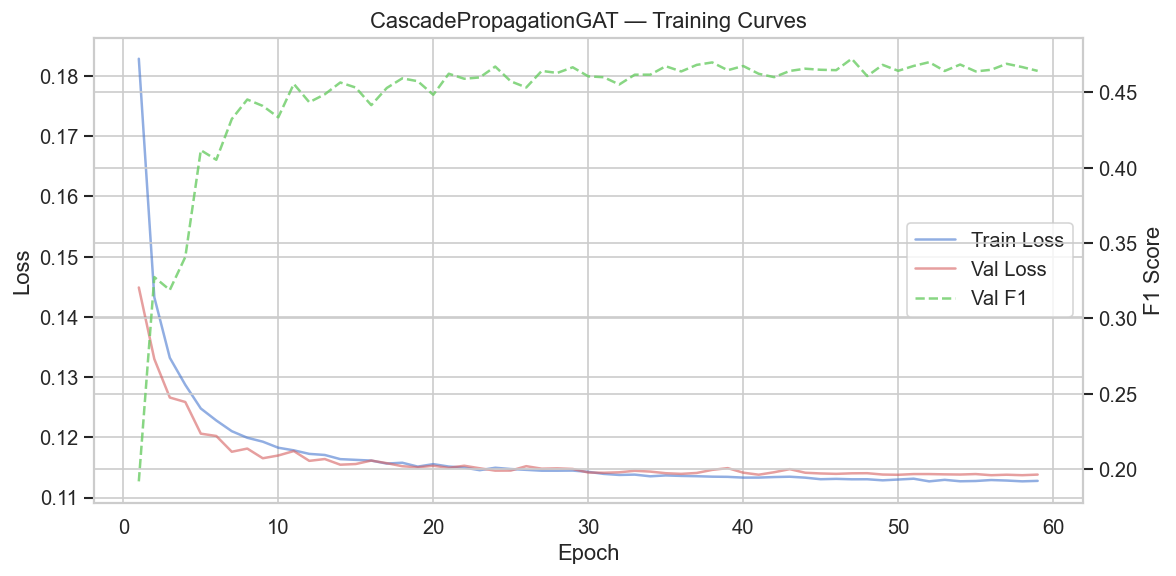

Model saved to ../models/gnn


In [50]:
# ── Save ──────────────────────────────────────────────────────────────
torch.save(model.state_dict(), MODEL_DIR / 'cascade_propagation_gat.pt')
with open(MODEL_DIR / 'gat_results.pkl', 'wb') as f:
    pickle.dump({
        'overall': overall,
        'per_label': per_label_df.to_dict(),
        'history': history,
        'thresholds': thresholds.tolist(),
        'target_names': TARGET_NAMES,
        'fips_to_idx': fips_to_idx,
    }, f)

# Training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
l1, = ax.plot(epochs_range, history['train_loss'], 'b-', alpha=0.6, label='Train Loss')
l2, = ax.plot(epochs_range, history['val_loss'], 'r-', alpha=0.6, label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax2 = ax.twinx()
l3, = ax2.plot(epochs_range, history['val_f1'], 'g--', alpha=0.8, label='Val F1')
ax2.set_ylabel('F1 Score')
ax.legend(handles=[l1, l2, l3], loc='center right')
ax.set_title('CascadePropagationGAT \u2014 Training Curves')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'gat_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Model saved to {MODEL_DIR}")

---
## 5. Cascade Propagation Visualization

Animate how the GNN propagates disaster risk from source counties outward:
1. **Seed**: Primary event lights up source county
2. **GAT Layer 1**: Risk spreads to immediate neighbors
3. **GAT Layer 2**: Risk reaches 2-hop counties
4. **Prediction**: Final cascade probability map

In [51]:
# ── Load county shapefile ─────────────────────────────────────────────
SHAPEFILE_CACHE = CACHE_DIR / 'us_counties.gpkg'
if SHAPEFILE_CACHE.exists():
    print("Loading cached county shapefile ...")
    counties_gdf = gpd.read_file(SHAPEFILE_CACHE)
else:
    print("Downloading county shapefile ...")
    tiger_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip"
    counties_gdf = gpd.read_file(tiger_url)
    counties_gdf.to_file(SHAPEFILE_CACHE, driver='GPKG')

counties_gdf['FIPS'] = counties_gdf['STATEFP'] + counties_gdf['COUNTYFP']
EXCLUDE_STATES = {'02', '15', '60', '66', '69', '72', '78'}
counties_conus = counties_gdf[~counties_gdf['STATEFP'].isin(EXCLUDE_STATES)].copy()
print(f"CONUS counties: {len(counties_conus)}")

Loading cached county shapefile ...
CONUS counties: 3108


In [52]:
# ── Pick a dramatic test episode to visualize ─────────────────────────
# Find episode with most counties affected by cascades
best_ep_data = None
best_score = 0
for d in test_data:
    n_cascade_counties = (d.y.sum(dim=1) > 0).sum().item()
    n_counties = d.x.shape[0]
    score = n_cascade_counties * n_counties  # big + spread
    if score > best_score and n_counties >= 10:
        best_score = score
        best_ep_data = d

ep = best_ep_data
print(f"Episode {ep.episode_id}: {ep.x.shape[0]} counties in subgraph")
print(f"  Source counties: {int(ep.is_source.sum())}")
print(f"  Counties with cascades: {(ep.y.sum(dim=1) > 0).sum().item()}")

# Get layer-by-layer activations for this episode
model.eval()
with torch.no_grad():
    x = ep.x_scaled.to(DEVICE)
    ei = ep.edge_index.to(DEVICE)
    is_src = ep.is_source.to(DEVICE)
    
    # Forward pass capturing intermediates
    h_input = torch.cat([x, is_src.unsqueeze(-1)], dim=-1)
    h0 = model.input_proj(h_input)
    
    h1_raw, attn1 = model.gat1(h0, ei, return_attention_weights=True)
    h1 = model.norm1(F.elu(h1_raw) + h0)
    
    h2_raw, attn2 = model.gat2(h1, ei, return_attention_weights=True)
    h2 = model.norm2(F.elu(h2_raw) + h1)
    
    logits = model.classifier(h2)
    probs = torch.sigmoid(logits)

stages = {
    'input': ep.is_source.numpy(),  # just source flag
    'proj': np.linalg.norm(h0.cpu().numpy(), axis=1),
    'gat1': np.linalg.norm(h1.cpu().numpy(), axis=1),
    'gat2': np.linalg.norm(h2.cpu().numpy(), axis=1),
    'probs': probs.cpu().numpy().max(axis=1),
}

# Map subgraph nodes back to global FIPS
global_ids = ep.global_node_ids.numpy()
ep_lons = county_coords.iloc[global_ids]['lon'].values
ep_lats = county_coords.iloc[global_ids]['lat'].values
ep_names = county_coords.iloc[global_ids]['name'].values
ep_states = county_coords.iloc[global_ids]['state'].values
ep_fips = [idx_to_fips[g] for g in global_ids]

# Source county info
src_mask = ep.is_source.numpy() > 0.5
src_names = [f"{ep_names[i]}, {ep_states[i]}" for i in range(len(src_mask)) if src_mask[i]]
print(f"  Source counties: {', '.join(src_names[:5])}")

# Actual cascade results
y_true = ep.y.numpy()
cascade_counties = [(ep_names[i], ep_states[i]) for i in range(len(y_true)) if y_true[i].sum() > 0]
print(f"  Cascade counties: {', '.join(f'{n}, {s}' for n,s in cascade_counties[:5])}")

Episode 201140: 102 counties in subgraph
  Source counties: 22
  Counties with cascades: 24
  Source counties: ADAIR, KENTUCKY, BARREN, KENTUCKY, BULLITT, KENTUCKY, BUTLER, KENTUCKY, CASEY, KENTUCKY
  Cascade counties: ADAIR, KENTUCKY, BARREN, KENTUCKY, BULLITT, KENTUCKY, BUTLER, KENTUCKY, CASEY, KENTUCKY


In [53]:
# ── Animated propagation for this episode ─────────────────────────────
STAGE_KEYS = ['input', 'proj', 'gat1', 'gat2', 'probs']
STAGE_LABELS = [
    'Primary Event \u2014 Source County',
    'Input Projection',
    'GAT Layer 1 \u2014 Neighbor Propagation',
    'GAT Layer 2 \u2014 2-Hop Spread',
    'Predicted Cascade Probability',
]

BACKGROUND = '#0a0e27'
NODE_CMAP = LinearSegmentedColormap.from_list(
    'disaster', ['#0a0e27', '#1b3a6b', '#2980b9', '#f39c12', '#e74c3c', '#ff1744'])
EDGE_CMAP = LinearSegmentedColormap.from_list(
    'attention', ['#0a0e2700', '#2980b944', '#f39c1288', '#e74c3ccc', '#ff1744ff'])

# Center view on this episode's counties
lon_center = np.mean(ep_lons)
lat_center = np.mean(ep_lats)
lon_range = max(np.ptp(ep_lons), 3) * 1.5
lat_range = max(np.ptp(ep_lats), 2) * 1.5

# Build edge segments for this subgraph
sub_ei = ep.edge_index.numpy()
edge_segs = []
edge_pairs = []
for e in range(sub_ei.shape[1]):
    s, d = sub_ei[0, e], sub_ei[1, e]
    if s != d:
        edge_segs.append([(ep_lons[s], ep_lats[s]), (ep_lons[d], ep_lats[d])])
        edge_pairs.append((s, d))

fig, ax = plt.subplots(figsize=(14, 9), facecolor=BACKGROUND)
fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)

# County boundaries as backdrop
counties_conus.boundary.plot(ax=ax, linewidth=0.15, color='#ffffff18')
ax.set_xlim(lon_center - lon_range/2, lon_center + lon_range/2)
ax.set_ylim(lat_center - lat_range/2, lat_center + lat_range/2)
ax.set_facecolor(BACKGROUND)
ax.set_axis_off()

title_text = ax.text(
    0.5, 0.97, '', transform=ax.transAxes, fontsize=15,
    color='white', fontweight='bold', ha='center', va='top',
    fontfamily='monospace',
    path_effects=[pe.withStroke(linewidth=3, foreground=BACKGROUND)])
sub_text = ax.text(
    0.5, 0.93, '', transform=ax.transAxes, fontsize=11,
    color='#8899bb', ha='center', va='top', fontfamily='monospace')

scatter = ax.scatter([], [], s=[], c=[], cmap=NODE_CMAP, zorder=5,
                     edgecolors='none', vmin=0, vmax=1)
lc = LineCollection([], linewidths=0.5, colors='#1a1f4e', zorder=2)
ax.add_collection(lc)

# Attention weights for GAT layers
attn1_ei = attn1[0].cpu().numpy()
attn1_w = attn1[1].cpu().numpy()
if attn1_w.ndim > 1: attn1_w = attn1_w.mean(axis=1)
attn2_ei = attn2[0].cpu().numpy()
attn2_w = attn2[1].cpu().numpy()
if attn2_w.ndim > 1: attn2_w = attn2_w.mean(axis=1)


def animate(frame_idx):
    stage = STAGE_KEYS[frame_idx]
    intensity = stages[stage]
    
    # Normalize to [0, 1]
    if stage == 'input':
        norm_intensity = intensity  # already 0/1
    elif stage == 'probs':
        norm_intensity = intensity  # already [0, 1]
    else:
        lo, hi = np.percentile(intensity, [5, 95])
        norm_intensity = np.clip((intensity - lo) / (hi - lo + 1e-8), 0, 1)
    
    sizes = 30 + norm_intensity * 200
    offsets = np.column_stack([ep_lons, ep_lats])
    scatter.set_offsets(offsets)
    scatter.set_array(norm_intensity)
    scatter.set_sizes(sizes)
    scatter.set_clim(0, 1)
    
    # Edge glow during GAT layers
    if stage in ('gat1', 'gat2'):
        a_ei = attn1_ei if stage == 'gat1' else attn2_ei
        a_w = attn1_w if stage == 'gat1' else attn2_w
        lookup = {}
        for e_i in range(a_ei.shape[1]):
            s, d = int(a_ei[0, e_i]), int(a_ei[1, e_i])
            if s != d:
                lookup[(s, d)] = float(a_w[e_i])
        
        ec, ew = [], []
        for (s, d) in edge_pairs:
            w = lookup.get((s, d), 0.0)
            w_n = min(w * 8, 1.0)
            ec.append(EDGE_CMAP(w_n))
            ew.append(0.3 + w_n * 3)
        lc.set_segments(edge_segs)
        lc.set_colors(ec)
        lc.set_linewidths(ew)
    else:
        lc.set_segments(edge_segs)
        lc.set_colors(['#1a1f4e'] * len(edge_segs))
        lc.set_linewidths([0.3] * len(edge_segs))
    
    title_text.set_text(f'Cascade Propagation \u2014 Episode {ep.episode_id}')
    sub_text.set_text(f'Stage {frame_idx+1}/{len(STAGE_KEYS)}: {STAGE_LABELS[frame_idx]}')
    return scatter, lc, title_text, sub_text


anim = FuncAnimation(fig, animate, frames=len(STAGE_KEYS),
                     interval=1500, blit=False, repeat=True)

gif_path = REPORTS_DIR / 'cascade_episode_propagation.gif'
anim.save(str(gif_path), writer=PillowWriter(fps=1), dpi=130,
          savefig_kwargs={'facecolor': BACKGROUND})
print(f"Saved: {gif_path}")

plt.close(fig)
from IPython.display import HTML
HTML(anim.to_jshtml())

Saved: ../results/gnn/cascade_episode_propagation.gif


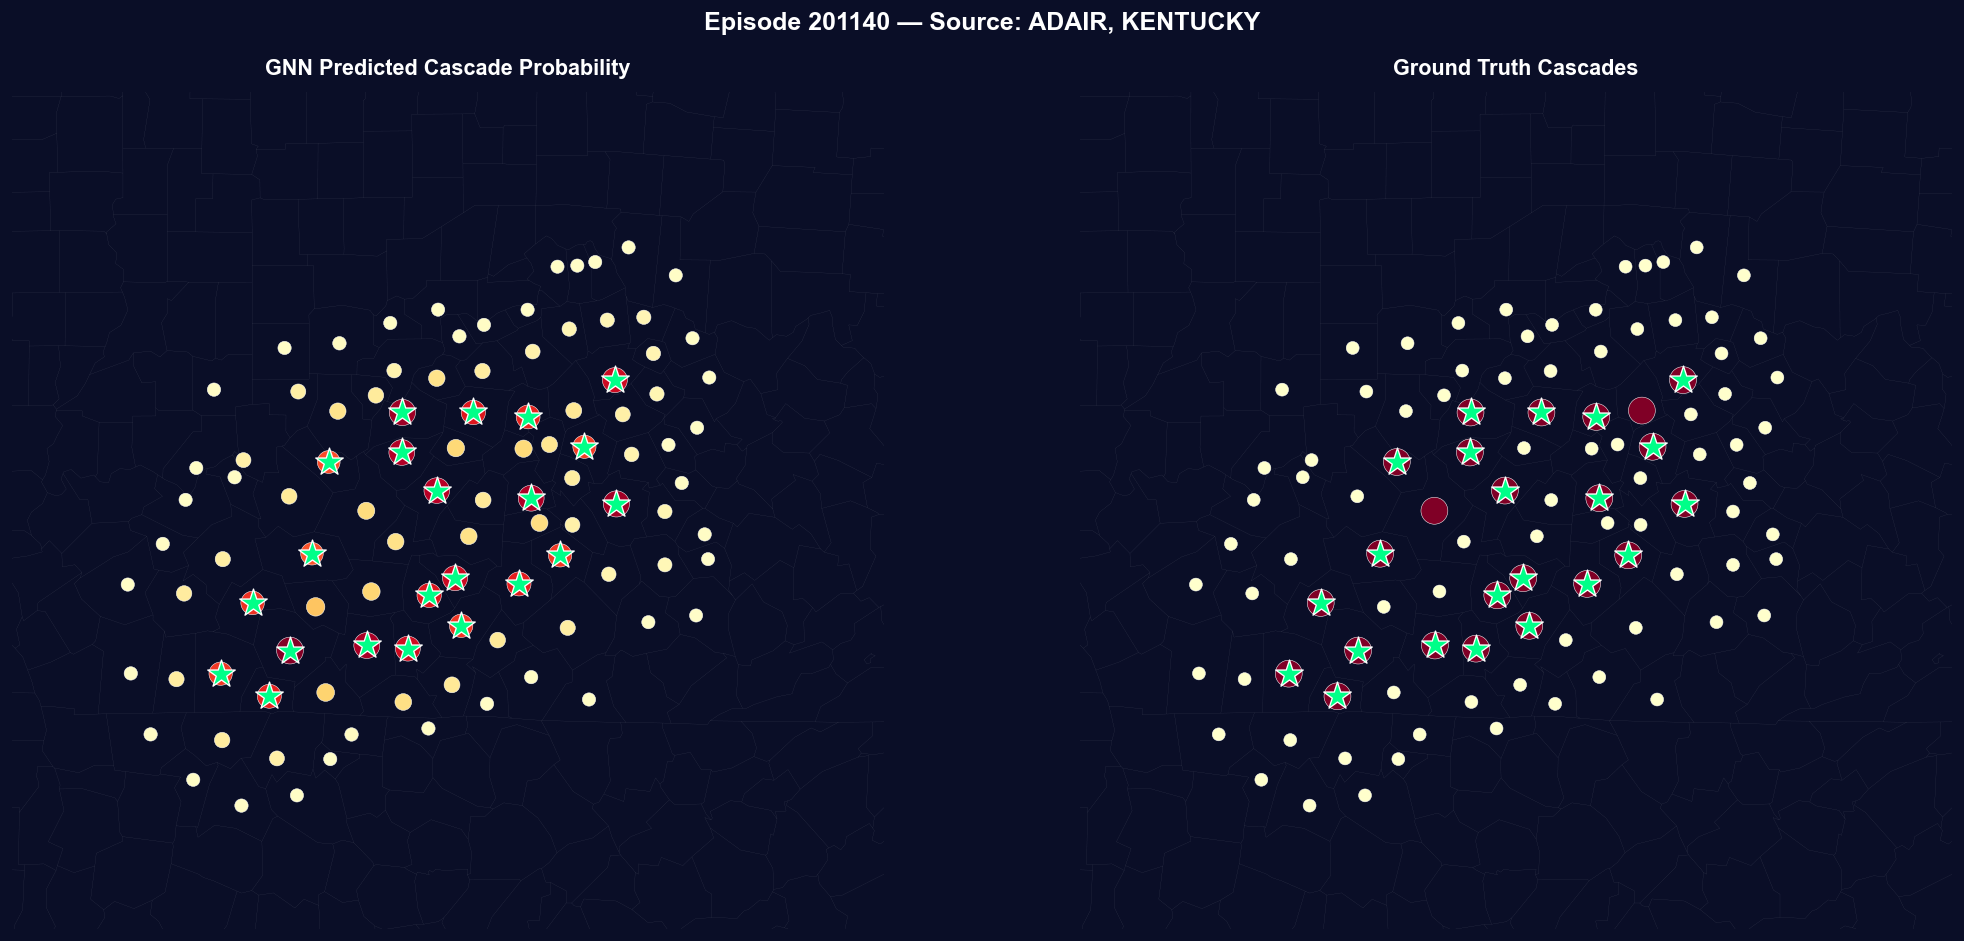

In [54]:
# ── Predicted vs Ground Truth map for the episode ─────────────────────
pred_probs = probs.cpu().numpy().max(axis=1)
true_cascade = ep.y.numpy().max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BACKGROUND)

for ax_i, (values, title, cmap_name) in enumerate([
    (pred_probs, 'GNN Predicted Cascade Probability', 'YlOrRd'),
    (true_cascade, 'Ground Truth Cascades', 'YlOrRd'),
]):
    ax = axes[ax_i]
    counties_conus.boundary.plot(ax=ax, linewidth=0.15, color='#ffffff18')
    ax.set_xlim(lon_center - lon_range/2, lon_center + lon_range/2)
    ax.set_ylim(lat_center - lat_range/2, lat_center + lat_range/2)
    ax.set_facecolor(BACKGROUND)
    ax.set_axis_off()
    
    # All subgraph nodes
    sc = ax.scatter(ep_lons, ep_lats, c=values, cmap=cmap_name,
                    s=60 + values * 200, vmin=0, vmax=1,
                    edgecolors='white', linewidth=0.3, zorder=5)
    
    # Mark source counties with stars
    src_lons = ep_lons[src_mask]
    src_lats = ep_lats[src_mask]
    ax.scatter(src_lons, src_lats, marker='*', s=300, c='#00ff88',
               edgecolors='white', linewidth=0.8, zorder=10)
    
    ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=10)

plt.suptitle(f'Episode {ep.episode_id} \u2014 Source: {src_names[0]}',
             fontsize=15, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'cascade_pred_vs_truth.png'), dpi=150,
            bbox_inches='tight', facecolor=BACKGROUND)
plt.show()

In [55]:
# ── Animate across multiple test episodes ─────────────────────────────
# Pick top 6 most interesting episodes (most cascade spread)
scored_episodes = []
for d in test_data:
    n_cascade = (d.y.sum(dim=1) > 0).sum().item()
    n_total = d.x.shape[0]
    if n_total >= 8 and n_cascade >= 2:
        scored_episodes.append((n_cascade, d))

scored_episodes.sort(key=lambda x: -x[0])
top_episodes = [d for _, d in scored_episodes[:6]]
print(f"Animating {len(top_episodes)} episodes")

# Pre-compute predictions
model.eval()
ep_viz_data = []
for d in top_episodes:
    with torch.no_grad():
        x_d = d.x_scaled.to(DEVICE)
        ei_d = d.edge_index.to(DEVICE)
        is_src_d = d.is_source.to(DEVICE)
        logits_d = model(x_d, ei_d, is_src_d)
        probs_d = torch.sigmoid(logits_d).cpu().numpy().max(axis=1)
    
    gids = d.global_node_ids.numpy()
    ep_viz_data.append({
        'ep_id': d.episode_id,
        'lons': county_coords.iloc[gids]['lon'].values,
        'lats': county_coords.iloc[gids]['lat'].values,
        'probs': probs_d,
        'true': d.y.numpy().max(axis=1),
        'source': d.is_source.numpy(),
        'names': county_coords.iloc[gids]['name'].values,
        'states': county_coords.iloc[gids]['state'].values,
    })

fig, ax = plt.subplots(figsize=(14, 8), facecolor=BACKGROUND)
fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)

title_t = ax.text(0.5, 0.97, '', transform=ax.transAxes, fontsize=14,
                  color='white', fontweight='bold', ha='center', va='top',
                  fontfamily='monospace',
                  path_effects=[pe.withStroke(linewidth=3, foreground=BACKGROUND)])
sub_t = ax.text(0.5, 0.93, '', transform=ax.transAxes, fontsize=11,
                color='#8899bb', ha='center', va='top', fontfamily='monospace')


def animate_multi(frame):
    ax.clear()
    counties_conus.boundary.plot(ax=ax, linewidth=0.1, color='#ffffff15')
    ax.set_facecolor(BACKGROUND)
    ax.set_axis_off()
    
    d = ep_viz_data[frame]
    
    # Auto-zoom
    cx, cy = d['lons'].mean(), d['lats'].mean()
    rx = max(np.ptp(d['lons']), 3) * 1.5
    ry = max(np.ptp(d['lats']), 2) * 1.5
    ax.set_xlim(cx - rx/2, cx + rx/2)
    ax.set_ylim(cy - ry/2, cy + ry/2)
    
    # Plot predicted probabilities
    ax.scatter(d['lons'], d['lats'], c=d['probs'], cmap='YlOrRd',
               s=60 + d['probs'] * 200, vmin=0, vmax=1,
               edgecolors='white', linewidth=0.3, zorder=5)
    
    # Source stars
    sm = d['source'] > 0.5
    ax.scatter(d['lons'][sm], d['lats'][sm], marker='*', s=300,
               c='#00ff88', edgecolors='white', linewidth=0.8, zorder=10)
    
    src_name = d['names'][sm][0] if sm.sum() > 0 else '?'
    src_state = d['states'][sm][0] if sm.sum() > 0 else ''
    n_spread = (d['true'] > 0).sum()
    
    ax.set_title(
        f'Episode {d["ep_id"]} \u2014 Source: {src_name}, {src_state}\n'
        f'{d["probs"].shape[0]} counties, {n_spread} with cascades',
        fontsize=13, fontweight='bold', color='white', pad=10)


anim_multi = FuncAnimation(fig, animate_multi, frames=len(ep_viz_data),
                           interval=2000, repeat=True)

multi_path = REPORTS_DIR / 'cascade_multi_episodes.gif'
anim_multi.save(str(multi_path), writer=PillowWriter(fps=0.7), dpi=130,
                savefig_kwargs={'facecolor': BACKGROUND})
print(f"Saved: {multi_path}")
plt.close(fig)
HTML(anim_multi.to_jshtml())

Animating 6 episodes
Saved: ../results/gnn/cascade_multi_episodes.gif


---
## 6. Summary

**What this model does differently from the tabular models (NB02-04):**
- Tabular models predict *what* cascade types a single event triggers
- This GNN predicts *where* cascades spread spatially across the county graph

**Fairness angle:**
- Counties with sparse reporting still get cascade predictions via neighbor signal
- The GAT attention weights show which county connections the model relies on

**Key outputs:**
- `cascade_episode_propagation.gif` \u2014 single episode step-by-step propagation
- `cascade_pred_vs_truth.png` \u2014 predicted vs actual cascade map
- `cascade_multi_episodes.gif` \u2014 multiple episodes animated

Saved glorious analysis map to: ../results/gnn/high_res_us_map_analysis.png


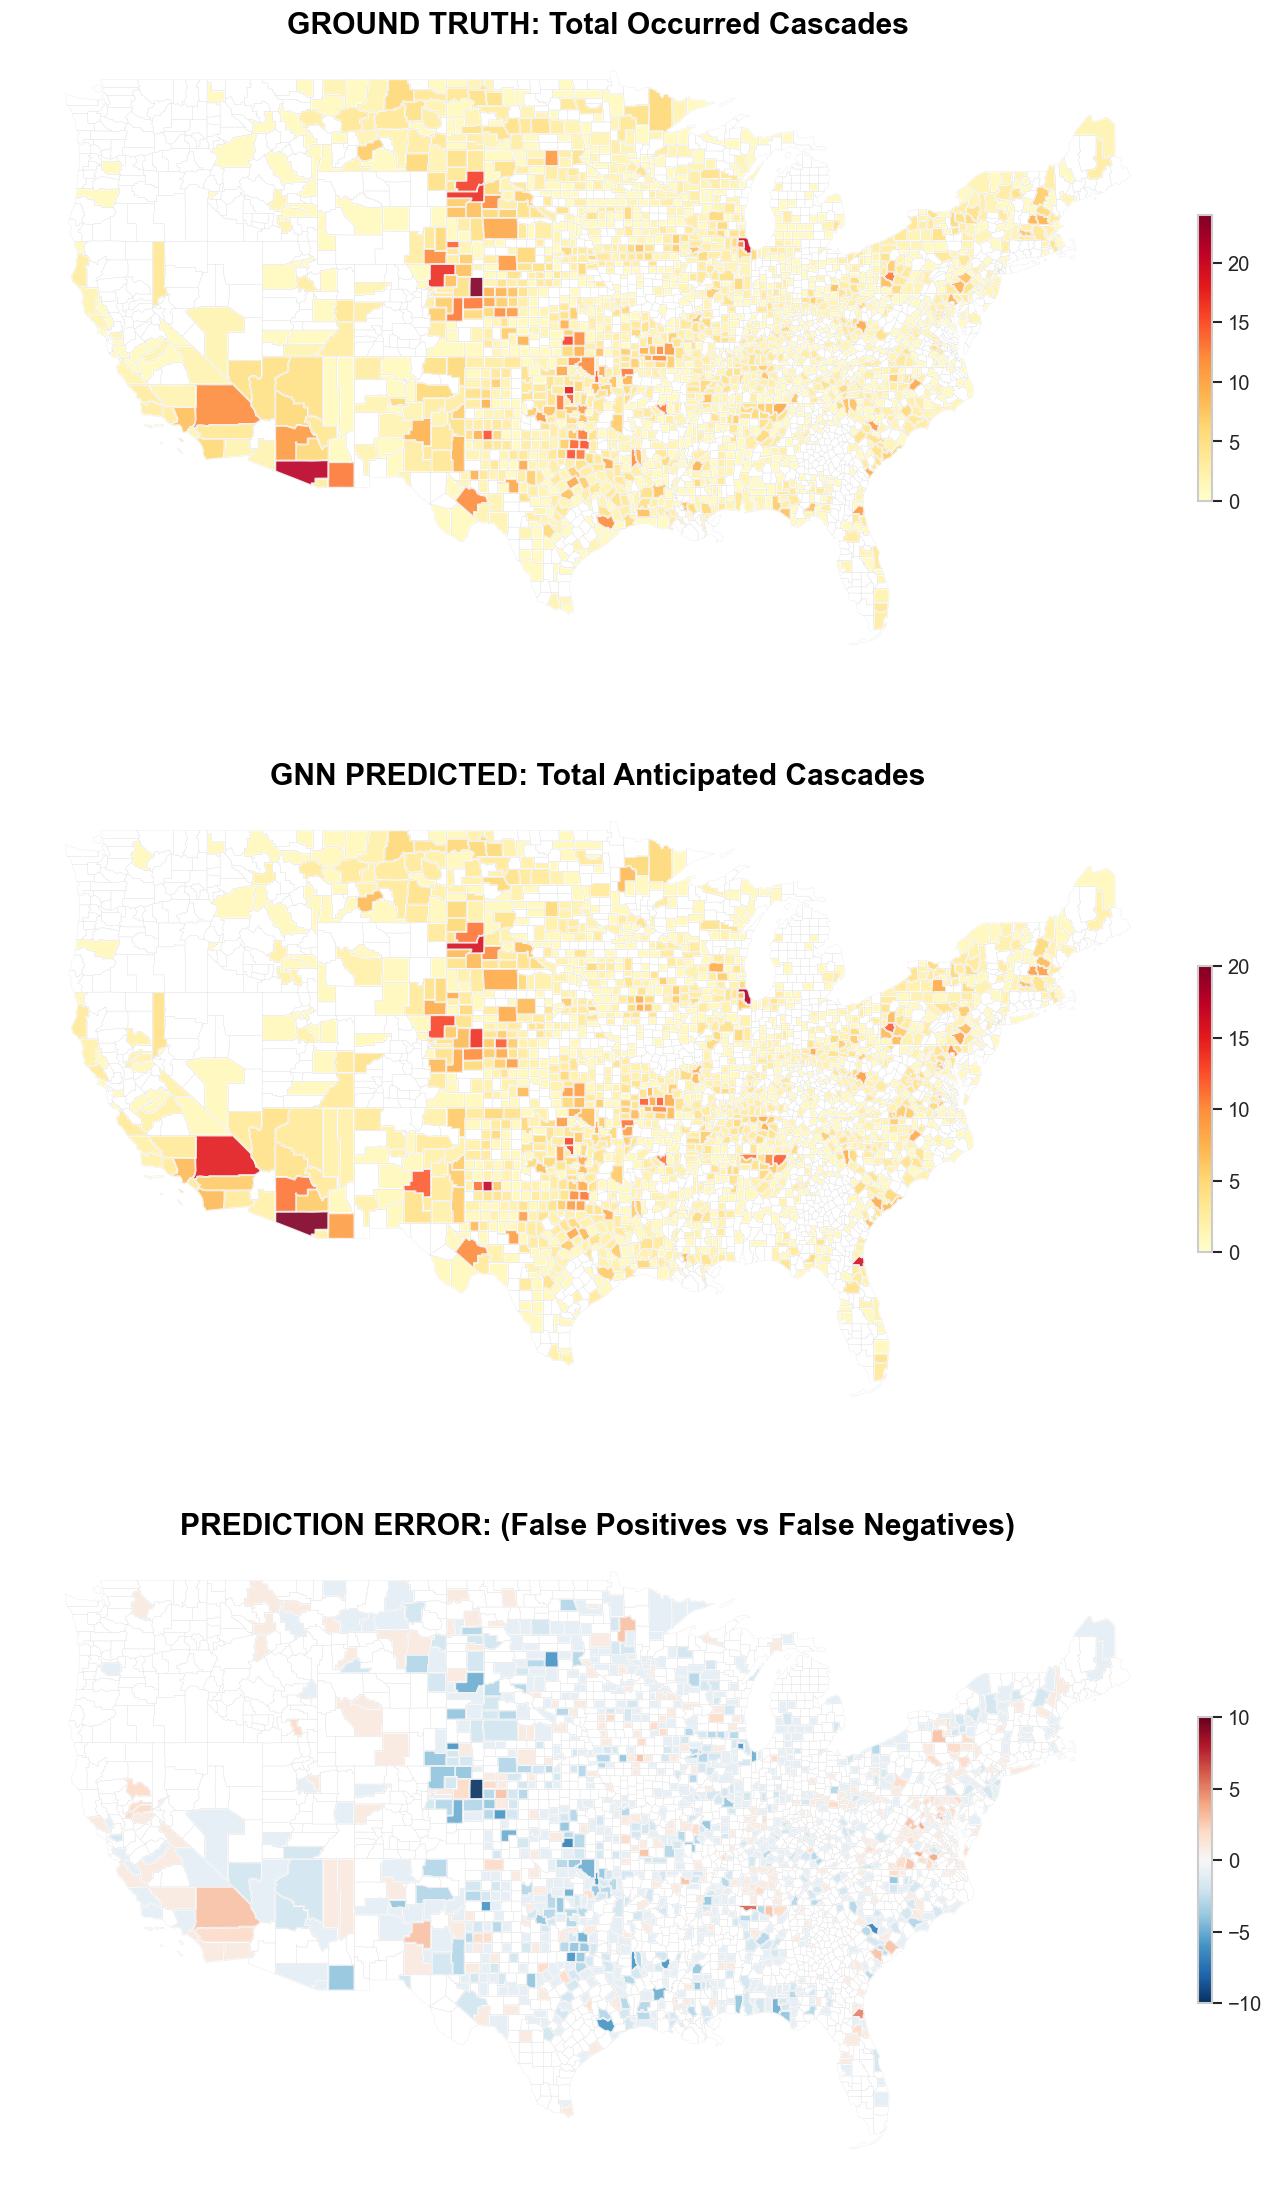

In [56]:
# ── 1. High-End Geographic Residuals Map ────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Accumulate probabilities and ground truth across all test episodes
total_pred = np.zeros(len(county_coords))
total_true = np.zeros(len(county_coords))

model.eval()
t_thresh = np.array(thresholds) if not hasattr(thresholds, "cpu") else thresholds.cpu().numpy()

for d in test_data:
    with torch.no_grad():
        logits_d = model(d.x_scaled.to(DEVICE), d.edge_index.to(DEVICE), d.is_source.to(DEVICE))
        probs_d = torch.sigmoid(logits_d).cpu().numpy()
    
    # Max over all cascade types per county
    preds_d = (probs_d >= t_thresh).astype(int).max(axis=1)
    true_d = d.y.numpy().max(axis=1)
    
    gids = d.global_node_ids.numpy()
    total_pred[gids] += preds_d
    total_true[gids] += true_d

temp_df = county_coords.copy().reset_index()
if "FIPS" not in temp_df.columns: temp_df = temp_df.rename(columns={"index": "FIPS"})
temp_df["pred_cascades"] = total_pred
temp_df["true_cascades"] = total_true

plot_df = counties_conus.merge(temp_df[["FIPS", "pred_cascades", "true_cascades"]], on="FIPS", how="left")
plot_df["pred_cascades"] = plot_df["pred_cascades"].fillna(0)
plot_df["true_cascades"] = plot_df["true_cascades"].fillna(0)
plot_df["residual Error"] = plot_df["pred_cascades"] - plot_df["true_cascades"]

# Map Plotting
bg = "#ffffff"  # White background
fig, axes = plt.subplots(3, 1, figsize=(15, 24), facecolor=bg)
fig.subplots_adjust(hspace=0.05)

max_err = max(abs(plot_df["residual Error"].min()), abs(plot_df["residual Error"].max()), 1)

panels = [
    ("true_cascades", "GROUND TRUTH: Total Occurred Cascades", "YlOrRd", 0, None),
    ("pred_cascades", "GNN PREDICTED: Total Anticipated Cascades", "YlOrRd", 0, None),
    ("residual Error", "PREDICTION ERROR: (False Positives vs False Negatives)", "RdBu_r", -max_err, max_err)
]

for ax, (col, title, cmap, vmin, vmax) in zip(axes, panels):
    ax.set_facecolor(bg)
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    # Plot base counties in light grey to blend with white background
    counties_conus.boundary.plot(ax=ax, linewidth=0.15, color="#dddddd")
    
    # Plot Heatmap with hotspots going extremely red
    active = plot_df[plot_df[col] != 0] if col == "residual Error" else plot_df[plot_df[col] > 0]
    if not active.empty:
        active.plot(column=col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.9, 
                    legend=True, legend_kwds={"shrink": 0.4, "pad": 0.01})
    
    # Aesthetic Title (Black text for white background)
    ax.set_title(title, fontsize=18, fontweight="bold", color="black", pad=5)

map_path = REPORTS_DIR / "high_res_us_map_analysis.png"
plt.savefig(str(map_path), dpi=200, bbox_inches="tight", facecolor=bg)
print(f"Saved glorious analysis map to: {map_path}")
plt.show()


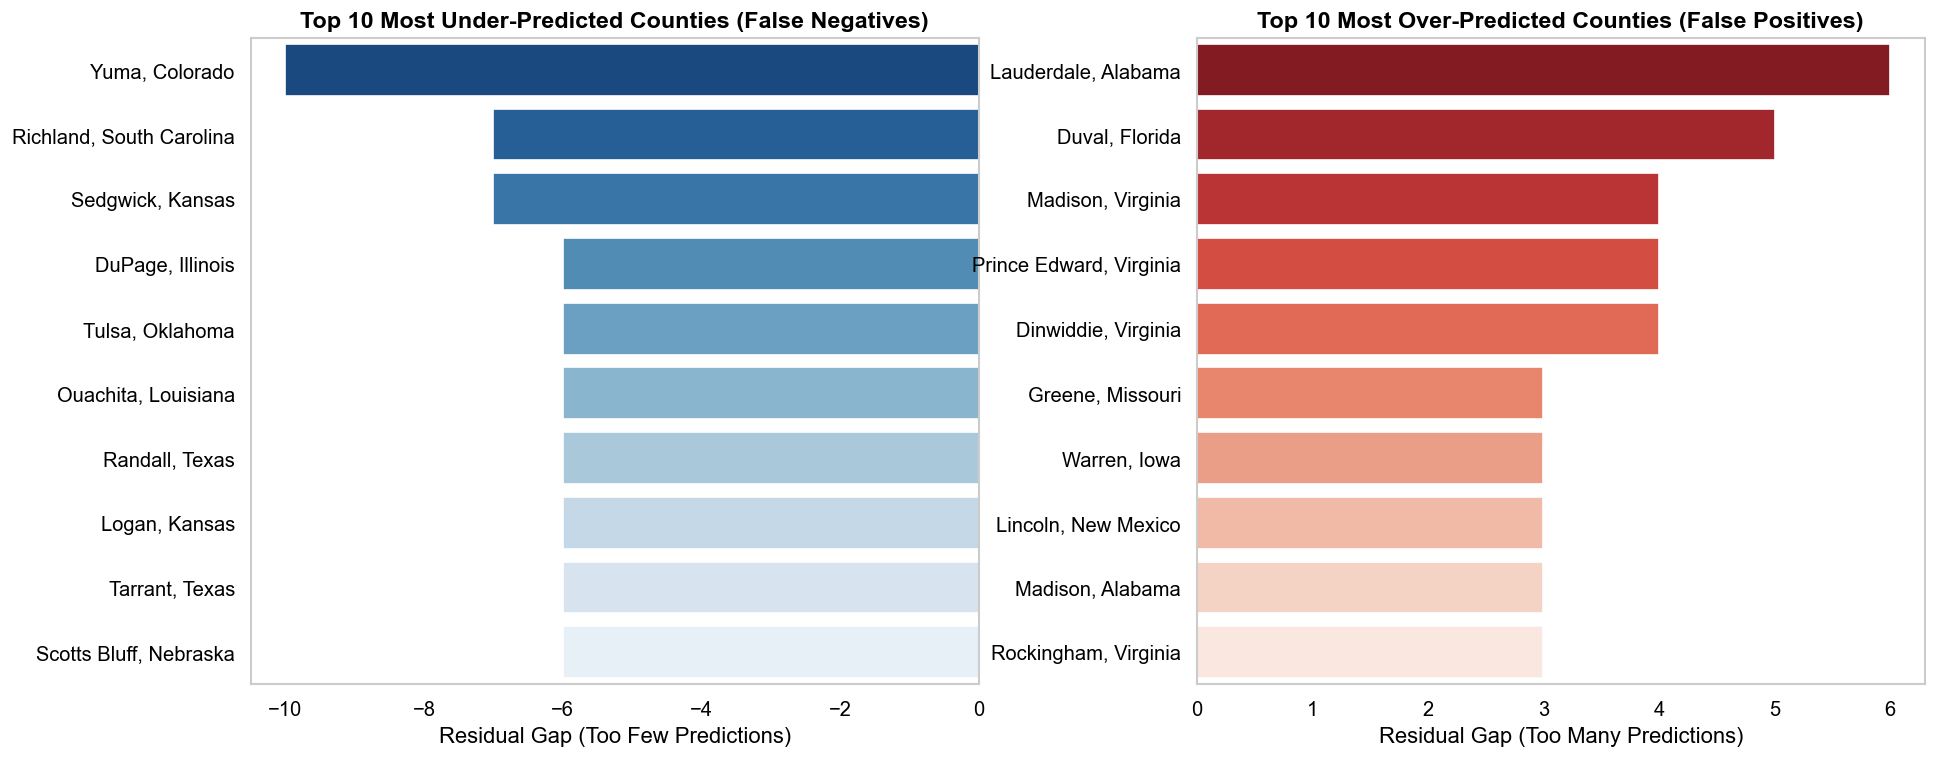

In [60]:
# ── 3. Spotlight on Model Blindspots (Hotspot Bars) ───────────────
import seaborn as sns

df_stats = plot_df.dropna(subset=["residual Error"]).copy()
df_stats["County_State"] = df_stats["NAME"] + ", " + df_stats["STATE_NAME"]

top_fn = df_stats.sort_values("residual Error").head(10)
top_fp = df_stats.sort_values("residual Error", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=bg)
fig.subplots_adjust(wspace=0.3)

sns.barplot(data=top_fn, y="County_State", x="residual Error", ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 Most Under-Predicted Counties (False Negatives)", color="black", weight="bold", size=14)
axes[0].set_xlabel("Residual Gap (Too Few Predictions)", color="black")

sns.barplot(data=top_fp, y="County_State", x="residual Error", ax=axes[1], palette="Reds_r")
axes[1].set_title("Top 10 Most Over-Predicted Counties (False Positives)", color="black", weight="bold", size=14)
axes[1].set_xlabel("Residual Gap (Too Many Predictions)", color="black")

for ax in axes:
    ax.set_ylabel("")
    ax.tick_params(colors="black")
    ax.grid(axis="x", color="#ffffff20")
    ax.set_facecolor(bg)

plt.savefig(str(REPORTS_DIR / "cascade_hotspots_bar.png"), dpi=150, bbox_inches="tight", facecolor=bg)
plt.show()
